In [ ]:
!pip install brian2
from brian2 import *
import numpy as np
import matplotlib.pyplot as plt

# setting up all the constants and params
plasticity_on = True
N_exc, N_inh = 8000, 2000
p = 0.02
tau_m, tau_syn_exc, tau_syn_inh = 20*ms, 5*ms, 10*ms
V_thr, V_reset, E_leak = -50*mV, -60*mV, -60*mV
I_b, g_bar = 200*pA, 3*nS
g_bar_II = 10 * g_bar

# stdp vars for the learning part
tau_stdp = 20*ms
rho_0 = 7.5*Hz
eta = 1e-3 if plasticity_on else 0
alpha = 0.14
w_max = 10.0

# defining the math for how neurons behave
neuron_eqs = '''
dv/dt = (g_leak*(E_leak - v) + I_exc + I_inh + I_b) / C_m : volt (unless refractory)
I_exc = g_exc * (0*mV - v) : amp
I_inh = g_inh * (-80*mV - v) : amp
dg_exc/dt = -g_exc / tau_syn_exc : siemens
dg_inh/dt = -g_inh / tau_syn_inh : siemens
dx/dt = -x / tau_stdp : 1
'''
C_m = 200*pF
g_leak = C_m / tau_m

start_scope()

# creating the actual neuron populations
G_exc = NeuronGroup(N_exc, neuron_eqs, threshold='v > V_thr',
                    reset='v = V_reset; x += 1', refractory=5*ms, method='euler')
G_inh = NeuronGroup(N_inh, neuron_eqs, threshold='v > V_thr',
                    reset='v = V_reset; x += 1', refractory=5*ms, method='euler')

G_exc.v = 'V_reset + rand() * (V_thr - V_reset)'
G_inh.v = 'V_reset + rand() * (V_thr - V_reset)'

# hooking up the synapses and setting weights
S_EE = Synapses(G_exc, G_exc, 'w : 1', on_pre='g_exc_post += w*g_bar', delay=0.001*ms)
S_EE.connect(p=p)
S_EE.w = 1.0

S_EI = Synapses(G_exc, G_inh, 'w : 1', on_pre='g_exc_post += w*g_bar')
S_EI.connect(p=p)
S_EI.w = 1.0

S_II = Synapses(G_inh, G_inh, 'w : 1', on_pre='g_inh_post += w*g_bar_II')
S_II.connect(p=p)
S_II.w = 1.0

# inhibitory plasticity logic
if plasticity_on:
    pre_logic = 'g_inh_post += w * g_bar_II; w = clip(w + eta * (x_post - alpha), 0, w_max)'
    post_logic = 'w = clip(w + eta * x_pre, 0, w_max)'
else:
    pre_logic = 'g_inh_post += w * g_bar_II'
    post_logic = ''

S_IE = Synapses(G_inh, G_exc, 'w : 1', on_pre=pre_logic, on_post=post_logic)
S_IE.connect(p=p)
S_IE.w = 0.1

# background noise to keep things moving
P_input_e = PoissonInput(G_exc, 'g_exc', N=50, rate=2*Hz, weight=0.05*g_bar)
P_input_i = PoissonInput(G_inh, 'g_exc', N=50, rate=2*Hz, weight=0.05*g_bar)

# setting up recorders to see what happens
stat_mon = StateMonitor(G_exc, ['v', 'I_exc', 'I_inh'], record=range(10))
weight_mon = StateMonitor(S_IE, 'w', record=range(5))
spikes_e = SpikeMonitor(G_exc)
rate_mon = PopulationRateMonitor(G_exc)

# initial run to reach steady state
initial_sim_time = 80*second
print(f"Simulating {initial_sim_time} for initial balancing...")
run(initial_sim_time)
store('balanced')

# creating a specific assembly by buffing weights
assembly_size = 500
assembly_indices = np.arange(0, assembly_size)
strengthening_factor = 5.0

is_in_asm = np.zeros(N_exc, dtype=bool)
is_in_asm[assembly_indices] = True
mask = is_in_asm[S_EE.i] & is_in_asm[S_EE.j]
S_EE.w[mask] *= strengthening_factor

# monitoring the assembly specifically
asm_mon = PopulationRateMonitor(G_exc[0:500])
ctrl_mon = PopulationRateMonitor(G_exc[1000:1500])

# final run to see how the network adapts
rebalance_time = 50*second
print(f"Simulating {rebalance_time} for assembly re-balancing...")
run(rebalance_time)


In [ ]:
sim_time = initial_sim_time + rebalance_time
current_sim_time_ms = sim_time / ms
zoom_window = 500
t_start = max(0, current_sim_time_ms - zoom_window)
t_end = current_sim_time_ms

fig, ax = plt.subplots(3, 1, figsize=(12, 12))

# excitatory and inhibitory currents
ax[0].plot(stat_mon.t/ms, stat_mon.I_exc[0]/nA, 'g', label='Exc. Current', alpha=0.8)
ax[0].plot(stat_mon.t/ms, stat_mon.I_inh[0]/nA, 'y', label='Inh. Current', alpha=0.8)
ax[0].set(ylabel='Current (nA)', title=f'Input Currents (Total Duration: {current_sim_time_ms}ms)')
ax[0].legend()

# membrane potential and the threshold line
ax[1].plot(stat_mon.t/ms, stat_mon.v[0]/mV, 'k', linewidth=0.5)
ax[1].axhline(V_thr/mV, color='r', linestyle='--')
ax[1].set(xlim=(t_start, t_end), ylabel='Voltage (mV)', title='Membrane Potential (Zoom)')

# spike raster
mask = (spikes_e.t/ms > t_start)
ax[2].plot(spikes_e.t[mask]/ms, spikes_e.i[mask], '.g', markersize=1)
ax[2].set(xlim=(t_start, t_end), xlabel='Time (ms)', ylabel='Neuron Index', title='Network Raster (Zoom)')

plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(12, 8))

if 'weight_mon' in locals():
    ax[0].plot(weight_mon.t/ms, weight_mon.w.T)
ax[0].set(title="Inhibitory Weight Evolution ($w_{IE}$)", ylabel="Weight", xlabel="Time (ms)")

ax[1].plot(rate_mon.t/ms, rate_mon.smooth_rate(window='gaussian', width=100*ms)/Hz)
ax[1].axhline(7, color='r', ls='--', label='Target (7.5Hz)')
ax[1].set(title="Population Firing Rate", ylabel="Rate (Hz)", xlabel="Time (ms)")
ax[1].legend()

plt.tight_layout()
plt.show()

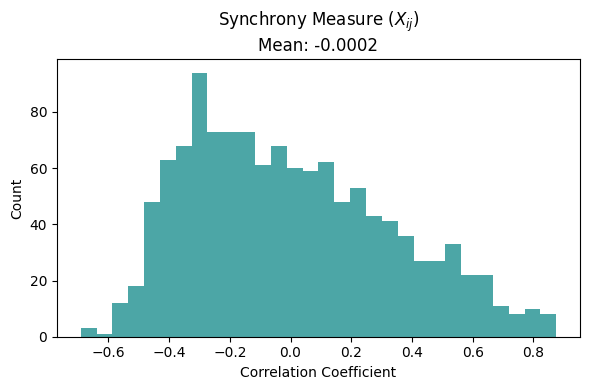

In [ ]:
def calculate_vogels_correlation(spike_monitor, sim_time, num_neurons=50, window_size=1.0*second):
    t_start = max(0*ms, sim_time - window_size)
    trains = spike_monitor.spike_trains()

    # Filter neurons with > 2 spikes in the window
    active = [i for i, t in trains.items() if np.sum((t >= t_start) & (t < sim_time)) > 2]
    if len(active) < 2:
        print("Warning: Insufficient active neurons.")
        return np.array([0])

    n = min(num_neurons, len(active))
    selected = np.random.choice(active, n, replace=False)

    # Define kernel (difference of exponentials)
    dt, tau1, tau2 = 1*ms, 50*ms, 200*ms
    t_k = np.arange(-500, 500) * ms
    kernel = (np.exp(-abs(t_k)/tau1)/tau1 - np.exp(-abs(t_k)/tau2)/tau2)
    kernel /= np.sum(abs(kernel))

    bins = np.arange(t_start/ms, sim_time/ms + 1, dt/ms)

    # Binned and filtered signals
    signals = []
    for i in selected:
        spikes = trains[i][(trains[i] >= t_start) & (trains[i] < sim_time)]
        counts, _ = np.histogram(spikes/ms, bins=bins)
        signals.append(np.convolve(counts, kernel, mode='same'))

    return np.corrcoef(signals)[np.triu_indices(n, k=1)]

# Execution and Plotting
corrs = calculate_vogels_correlation(spikes_e, sim_time)
plt.figure(figsize=(6, 4))
plt.hist(corrs, bins=30, color='teal', alpha=0.7)
plt.title(f"Synchrony Measure ($X_{{ij}}$)\nMean: {np.mean(corrs):.4f}")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

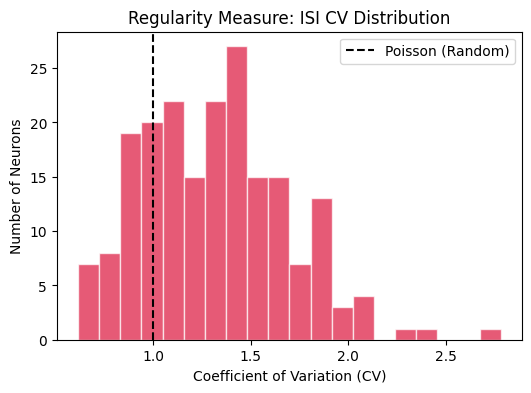

Mean ISI CV: 1.3157


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- REGULARITY ANALYSIS (ISI CV HISTOGRAM) ---
trains = spikes_e.spike_trains()
cv_list = []

# Select neurons active in the last 1 second
t_start_cv = sim_time - 1*second
active_ids = [i for i in trains.keys() if len(trains[i][trains[i] > t_start_cv]) > 5]

# Sample 200 neurons for a better histogram
sample_ids = np.random.choice(active_ids, min(200, len(active_ids)), replace=False)

for i in sample_ids:
    t_spikes = trains[i][trains[i] > t_start_cv]
    isi = np.diff(t_spikes)
    cv_val = np.std(isi) / np.mean(isi)
    cv_list.append(cv_val)

# Plotting the Regularity Histogram
plt.figure(figsize=(6, 4))
plt.hist(cv_list, bins=20, color='crimson', edgecolor='white', alpha=0.7)
plt.axvline(1.0, color='k', linestyle='--', label='Poisson (Random)')
plt.title("Regularity Measure: ISI CV Distribution")
plt.xlabel("Coefficient of Variation (CV)")
plt.ylabel("Number of Neurons")
plt.legend()
plt.show()

print(f"Mean ISI CV: {np.mean(cv_list):.4f}")

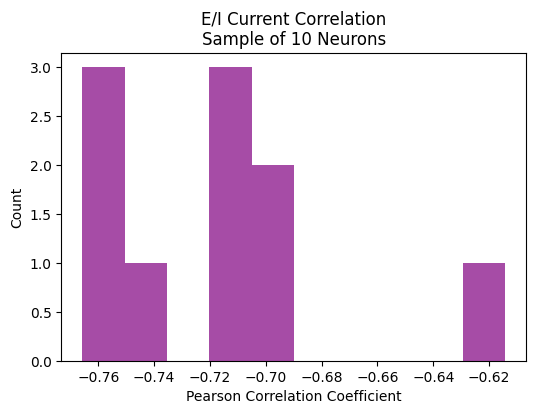

In [ ]:
num_available_neurons = len(stat_mon.I_exc)
num_neurons_sample = min(20, num_available_neurons)  # Automatically adjust to available neurons
if num_available_neurons < 2:
    print(f"Not enough neurons to sample (only {num_available_neurons} available). Skipping correlation plot.")
    ei_corrs = []
else:
    neuron_indices = np.random.choice(num_available_neurons, num_neurons_sample, replace=False)
    ei_corrs = []
    for idx in neuron_indices:
        i_exc = stat_mon.I_exc[idx] / nA
        i_inh = stat_mon.I_inh[idx] / nA
        # Remove mean for correlation
        sig_e = i_exc - np.mean(i_exc)
        sig_i = i_inh - np.mean(i_inh)
        # Compute Pearson correlation coefficient
        corr = np.corrcoef(sig_e, sig_i)[0, 1]
        ei_corrs.append(corr)

    plt.figure(figsize=(6, 4))
    plt.hist(ei_corrs, bins=10, color='purple', alpha=0.7)
    plt.title(f'E/I Current Correlation\nSample of {num_neurons_sample} Neurons')
    plt.xlabel('Pearson Correlation Coefficient')
    plt.ylabel('Count')
    plt.show()

peak correlation: 0.9485
biological lag: 1.10 ms


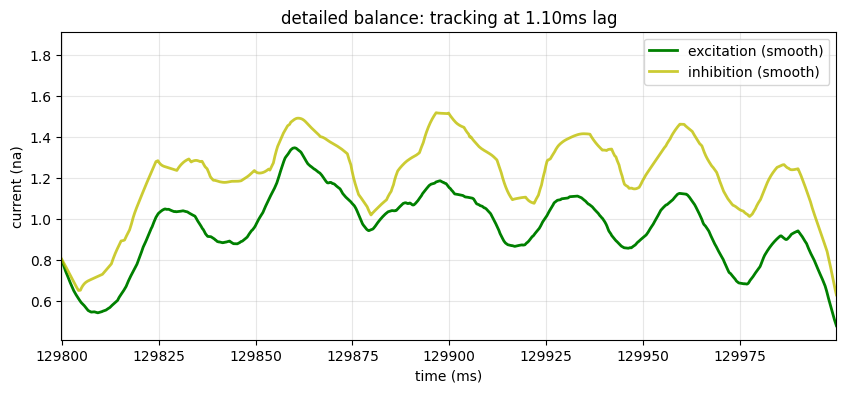

In [ ]:
# --- final corrected part 4: detailed balance analysis ---
from scipy import signal

# look at the last 1 second
t_end_val = stat_mon.t[-1]
t_start_val = t_end_val - 1*second
mask = (stat_mon.t >= t_start_val) & (stat_mon.t <= t_end_val)

i_ex = stat_mon.I_exc[0][mask] / nA
i_in = -stat_mon.I_inh[0][mask] / nA # flip to positive for comparison
time_ms = stat_mon.t[mask] / ms

# use 20ms smoothing to see the 'envelope' tracking (vogels style)
win = int(20*ms / defaultclock.dt)
i_ex_s = np.convolve(i_ex, np.ones(win)/win, mode='same')
i_in_s = np.convolve(i_in, np.ones(win)/win, mode='same')

# calculate cross-correlation
sig_e = i_ex_s - np.mean(i_ex_s)
sig_i = i_in_s - np.mean(i_in_s)
corr_vals = signal.correlate(sig_i, sig_e, mode='same')
lags = signal.correlation_lags(len(sig_i), len(sig_e), mode='same')
lags_ms = lags * (defaultclock.dt / ms)

# strict causal search: force lag between 1ms and 15ms
causal = (lags_ms > 1.0) & (lags_ms < 15.0)
best_lag = lags_ms[causal][np.argmax(corr_vals[causal])]

# calculate correlation at this best lag
shift = int(best_lag / (defaultclock.dt/ms))
i_in_shifted = np.roll(i_in_s, -shift)
p_corr = np.corrcoef(i_ex_s[200:-200], i_in_shifted[200:-200])[0, 1]

print(f"peak correlation: {p_corr:.4f}")
print(f"biological lag: {best_lag:.2f} ms")

# plot tracking (zoom to 200ms)
plt.figure(figsize=(10, 4))
plt.plot(time_ms, i_ex_s, 'g', label='excitation (smooth)', linewidth=2)
plt.plot(time_ms, i_in_s, 'y', label='inhibition (smooth)', linewidth=2, alpha=0.8)
plt.xlim(time_ms[-1]-200, time_ms[-1])
plt.title(f"detailed balance: tracking at {best_lag:.2f}ms lag")
plt.xlabel("time (ms)"); plt.ylabel("current (na)")
plt.legend(); plt.grid(alpha=0.3); plt.show()

Imprinting assembly using nested loop method...
Modified/created 12464 connections within assembly.
Simulating 20.0s for Re-balancing...


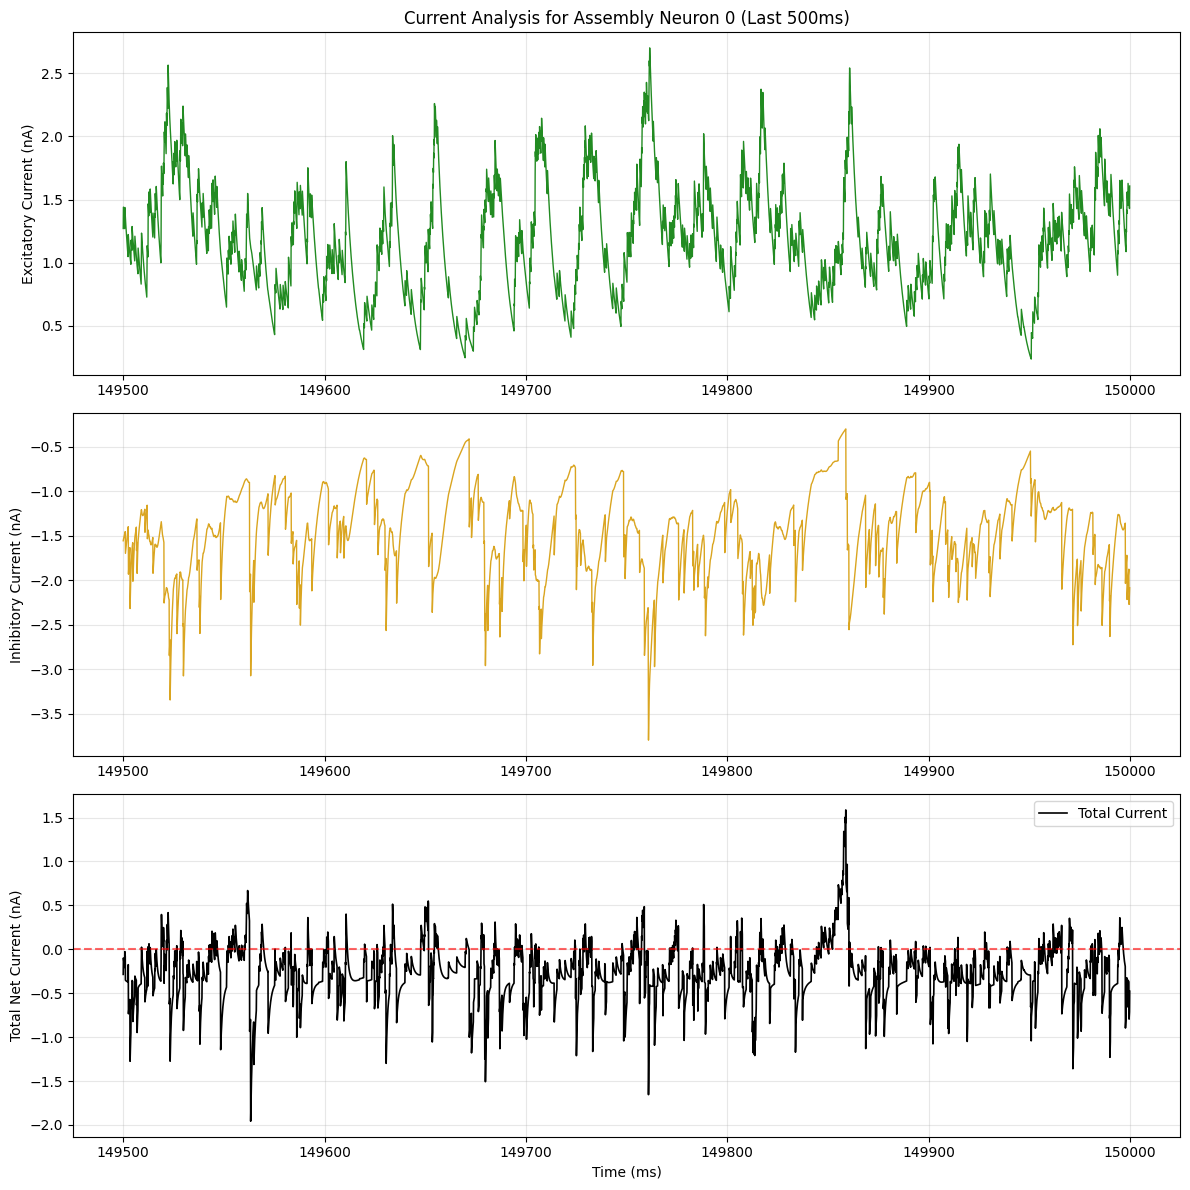

In [ ]:
# ---- Parameters for Step 4 ----
rho_0 = alpha / (2 * tau_stdp)
assembly_start = 0
assembly_end = 500
assembly_indices = np.arange(assembly_start, assembly_end)

prc = 0.05  # Connection probability within the assembly
w_assembly = 1.0  # Weight for new assembly connections

# ---- EXACT SAME METHOD: Nested Loop on S_EE ----
num_connections_modified = 0
print("Imprinting assembly using nested loop method...")

for i in assembly_indices:
    for j in assembly_indices:
        if i != j and np.random.rand() < prc:
            # Check if connection exists in original S_EE
            existing = (S_EE.i == i) & (S_EE.j == j)
            if np.any(existing):
                # Strengthen existing connection
                idx = np.where(existing)[0][0]
                S_EE.w[idx] *= 2.0
            else:
                # Create new connection on original S_EE
                S_EE.connect(i=i, j=j)
                S_EE.w[-1] = w_assembly
            num_connections_modified += 1

print(f"Modified/created {num_connections_modified} connections within assembly.")

# ---- Monitors ----
assembly_group = G_exc[assembly_start:assembly_end]
assembly_rate_mon = PopulationRateMonitor(assembly_group)

# ---- Run Re-balancing ----
rebalance_time = 20000*ms
print(f"Simulating {rebalance_time/second}s for Re-balancing...")
run(rebalance_time)

# ---- PLOTTING THE THREE CURRENTS ----

target_neuron = 0 # Neuron 0 is inside the assembly
time_ms = stat_mon.t / ms

# Extract currents (convert to nA)
# Note: Brian2 currents are signed, so Total = Exc + Inh
i_exc = stat_mon.I_exc[target_neuron] / nA
i_inh = stat_mon.I_inh[target_neuron] / nA
i_total = i_exc + i_inh

# Zoom into the last 500ms for high detail
zoom_mask = (time_ms > (time_ms[-1] - 500))

plt.figure(figsize=(12, 12))

# Graph 1: Excitatory Current
plt.subplot(3, 1, 1)
plt.plot(time_ms[zoom_mask], i_exc[zoom_mask], color='forestgreen', linewidth=1)
plt.title(f'Current Analysis for Assembly Neuron {target_neuron} (Last 500ms)')
plt.ylabel('Excitatory Current (nA)')
plt.grid(True, alpha=0.3)

# Graph 2: Inhibitory Current
plt.subplot(3, 1, 2)
plt.plot(time_ms[zoom_mask], i_inh[zoom_mask], color='goldenrod', linewidth=1)
plt.ylabel('Inhibitory Current (nA)')
plt.grid(True, alpha=0.3)

# Graph 3: Total Current (Net Balance)
plt.subplot(3, 1, 3)
plt.plot(time_ms[zoom_mask], i_total[zoom_mask], color='black', linewidth=1.2, label='Total Current')
plt.axhline(0, color='red', linestyle='--', alpha=0.6)
plt.ylabel('Total Net Current (nA)')
plt.xlabel('Time (ms)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# ---- Parameters for Step 4 ----
alpha = 0.3
rho_0 = alpha / (2 * tau_stdp) # This is 7.5 Hz
assembly_start = 0
assembly_end = 500
assembly_indices = np.arange(assembly_start, assembly_end)

prc = 0.05  # Connection probability within the assembly
w_assembly = 1.0  # Weight for new assembly connections

# ---- EXACT SAME METHOD: Nested Loop on S_EE ----
num_connections_modified = 0
print("Imprinting assembly using nested loop method...")

for i in assembly_indices:
    for j in assembly_indices:
        if i != j and np.random.rand() < prc:
            existing = (S_EE.i == i) & (S_EE.j == j)
            if np.any(existing):
                idx = np.where(existing)[0][0]
                S_EE.w[idx] *= 2.0
            else:
                S_EE.connect(i=i, j=j)
                S_EE.w[-1] = w_assembly
            num_connections_modified += 1

print(f"Modified/created {num_connections_modified} connections within assembly.")

# ---- NEW MONITORS FOR FIRING RATES ----
# 1. Monitor for the Excitatory Assembly
assembly_rate_mon = PopulationRateMonitor(G_exc[assembly_start:assembly_end])
# 2. Monitor for the Inhibitory Population
inh_rate_mon = PopulationRateMonitor(G_inh)
# 3. Monitor for the Total Excitatory Population (to calculate total network rate)
exc_total_rate_mon = PopulationRateMonitor(G_exc)

# ---- Run Re-balancing ----
rebalance_time = 20000*ms
print(f"Simulating {rebalance_time/second}s for Re-balancing...")
run(rebalance_time)

# ---- PLOTTING THE THREE FIRING RATES ----

# Use a 100ms window for smoothing to see the trends clearly
smooth_win = 100*ms
t_ms = assembly_rate_mon.t / ms

# Calculate rates in Hz
rate_exc_asm = assembly_rate_mon.smooth_rate(window='gaussian', width=smooth_win) / Hz
rate_inh     = inh_rate_mon.smooth_rate(window='gaussian', width=smooth_win) / Hz

# Total Network Rate (Weighted average of E and I)
# (N_exc * R_exc + N_inh * R_inh) / (N_exc + N_inh)
rate_total = (N_exc * (exc_total_rate_mon.smooth_rate(window='gaussian', width=smooth_win)/Hz) +
              N_inh * (inh_rate_mon.smooth_rate(window='gaussian', width=smooth_win)/Hz)) / (N_exc + N_inh)

plt.figure(figsize=(12, 12))

# Graph 1: Excitatory Assembly Firing Rate
plt.subplot(3, 1, 1)
plt.plot(t_ms, rate_exc_asm, color='red', linewidth=1.5)
plt.axhline(rho_0/Hz, color='black', linestyle='--', alpha=0.6, label=f'Target ({rho_0/Hz:.1f} Hz)')
plt.title('Firing Rate Analysis: Step 4 Re-balancing')
plt.ylabel('Exc. Assembly Rate (Hz)')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

# Graph 2: Inhibitory Population Firing Rate
plt.subplot(3, 1, 2)
plt.plot(t_ms, rate_inh, color='blue', linewidth=1.5)
plt.axhline(rho_0/Hz, color='black', linestyle='--', alpha=0.6, label=f'Target ({rho_0/Hz:.1f} Hz)')
plt.ylabel('Inhibitory Rate (Hz)')
plt.grid(True, alpha=0.3)

# Graph 3: Total Network Firing Rate
plt.subplot(3, 1, 3)
plt.plot(t_ms, rate_total, color='black', linewidth=1.5)
plt.axhline(rho_0/Hz, color='black', linestyle='--', alpha=0.6, label=f'Target ({rho_0/Hz:.1f} Hz)')
plt.ylabel('Total Network Rate (Hz)')
plt.xlabel('Time (ms)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final Assembly Rate: {rate_exc_asm[-1]:.2f} Hz")
print(f"Final Inhibitory Rate: {rate_inh[-1]:.2f} Hz")
print(f"Final Total Network Rate: {rate_total[-1]:.2f} Hz")

Imprinting assembly using nested loop method...
Modified/created 12439 connections within assembly.
Simulating 20.0s for Re-balancing...


In [ ]:
# ---- Parameters for Step 4 ----
alpha = 0.3
rho_0 = alpha / (2 * tau_stdp) # This is 7.5 Hz
assembly_start = 0
assembly_end = 500
assembly_indices = np.arange(assembly_start, assembly_end)

prc = 0.05
w_assembly = 1.0

# ---- EXACT SAME METHOD: Nested Loop on S_EE ----
num_connections_modified = 0
print("Imprinting assembly using nested loop method...")

for i in assembly_indices:
    for j in assembly_indices:
        if i != j and np.random.rand() < prc:
            existing = (S_EE.i == i) & (S_EE.j == j)
            if np.any(existing):
                idx = np.where(existing)[0][0]
                S_EE.w[idx] *= 2.0
            else:
                S_EE.connect(i=i, j=j)
                S_EE.w[-1] = w_assembly
            num_connections_modified += 1

print(f"Modified/created {num_connections_modified} connections within assembly.")

# ---- MONITORS ----
# Create monitors before the run to capture the re-balancing process
assembly_rate_mon = PopulationRateMonitor(G_exc[assembly_start:assembly_end])
inh_rate_mon      = PopulationRateMonitor(G_inh)
exc_total_rate_mon = PopulationRateMonitor(G_exc)

# ---- Run Re-balancing ----
rebalance_time = 20000*ms
print(f"Simulating {rebalance_time/second}s for Re-balancing...")
run(rebalance_time)

# ---- DATA PROCESSING ----
smooth_win = 100*ms
t_ms = assembly_rate_mon.t / ms

# Calculate rates in Hz
r_exc_asm = assembly_rate_mon.smooth_rate(window='gaussian', width=smooth_win) / Hz
r_inh     = inh_rate_mon.smooth_rate(window='gaussian', width=smooth_win) / Hz
r_total_exc = exc_total_rate_mon.smooth_rate(window='gaussian', width=smooth_win) / Hz

# Total Network Rate (weighted average of all 10,000 neurons)
r_total = (N_exc * r_total_exc + N_inh * r_inh) / (N_exc + N_inh)

# Determine the maximum rate to set the same scale for all plots
max_val = max(np.max(r_exc_asm), np.max(r_inh), np.max(r_total))
y_limit = max_val * 1.1 # add 10% padding

# ---- PLOTTING THE THREE FIRING RATES ----
plt.figure(figsize=(12, 12))

# Graph 1: Excitatory Assembly Firing Rate
plt.subplot(3, 1, 1)
plt.plot(t_ms, r_exc_asm, color='red', linewidth=1.5, label='Assembly Rate')
plt.axhline(rho_0/Hz, color='black', linestyle='--', linewidth=2, label=f'Target ({rho_0/Hz:.1f} Hz)')
plt.title('Step 4 Analysis: Homeostatic Re-balancing (Uniform Scale)')
plt.ylabel('Exc. Assembly (Hz)')
plt.ylim(0, y_limit)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

# Graph 2: Inhibitory Population Firing Rate
plt.subplot(3, 1, 2)
plt.plot(t_ms, r_inh, color='blue', linewidth=1.5, label='Inhibitory Rate')
plt.axhline(rho_0/Hz, color='black', linestyle='--', linewidth=2)
plt.ylabel('Inhibitory Pop (Hz)')
plt.ylim(0, y_limit)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

# Graph 3: Total Network Firing Rate
plt.subplot(3, 1, 3)
plt.plot(t_ms, r_total, color='black', linewidth=1.5, label='Total Network Rate')
plt.axhline(rho_0/Hz, color='black', linestyle='--', linewidth=2)
plt.ylabel('Total Network (Hz)')
plt.xlabel('Time (ms)')
plt.ylim(0, y_limit)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final Assembly Rate: {r_exc_asm[-1]:.2f} Hz")
print(f"Final Total Network Rate: {r_total[-1]:.2f} Hz")